# Car Price Prediction with Machine Learning

**Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

**Dataset:** 301 used car listings with the car's name, manufacture year, selling price, original ex-showroom ("present") price, kilometers driven, fuel type, seller type, transmission type, and number of previous owners.

**Workflow:**
1. Load & inspect the data
2. Data cleaning
3. Feature engineering (car age, brand extraction)
4. Exploratory Data Analysis
5. Encode categorical variables
6. Correlation heatmap
7. Train/test split
8. Train 2+ regression models
9. Evaluate with MAE, RMSE, R²
10. Feature importance for the best model


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 1. Load Dataset & Initial Inspection

In [2]:
df = pd.read_csv('car_data.csv')
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Shape: 301 rows, 9 columns


In [4]:
df.dtypes


Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object

In [5]:
# Null value check
df.isnull().sum()


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [6]:
# Duplicate rows check
print(f"Duplicate rows: {df.duplicated().sum()}")


Duplicate rows: 2


## 2. Data Cleaning

In [7]:
# Drop exact duplicate rows, if any
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate row(s). New shape: {df.shape}")


Removed 2 duplicate row(s). New shape: (299, 9)


In [8]:
# Check categorical columns for inconsistent casing/spelling (e.g. 'Petrol' vs 'petrol')
for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    print(col, ':', df[col].unique())


Fuel_Type : <StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Seller_Type : <StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission : <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


**Observation:** The categorical columns in this dataset are already consistently capitalised (no `'Petrol'` vs `'petrol'`-style mismatches), so no case-normalisation is required here. In messier real-world scrapes this step is essential — we still standardise defensively below using `.str.strip().str.title()` in case of hidden whitespace.

In [9]:
for col in ['Fuel_Type', 'Seller_Type', 'Transmission']:
    df[col] = df[col].astype(str).str.strip().str.title()


## 3. Feature Engineering

In [10]:
# Reference year: this dataset was compiled around 2020, so we calculate car age relative to that
CURRENT_YEAR = 2020

df['Car_Age'] = CURRENT_YEAR - df['Year']

# Extract the brand as the first word of the car name (e.g. 'ritz' -> 'ritz', 'land cruiser' -> 'land')
df['Brand'] = df['Car_Name'].str.split().str[0].str.lower()

df[['Car_Name', 'Year', 'Car_Age', 'Brand']].head()


,Car_Name,Year,Car_Age,Brand
0,ritz,2014,6,ritz
1,sx4,2013,7,sx4
2,ciaz,2017,3,ciaz
3,wagon r,2011,9,wagon
4,swift,2014,6,swift


In [11]:
print(f"Number of distinct brands: {df['Brand'].nunique()}")
df['Brand'].value_counts().head(10)


Number of distinct brands: 44


Brand
city        26
bajaj       25
corolla     17
royal       17
honda       17
hero        15
verna       14
etios       11
fortuner    10
brio        10
Name: count, dtype: int64

## 4. Exploratory Data Analysis

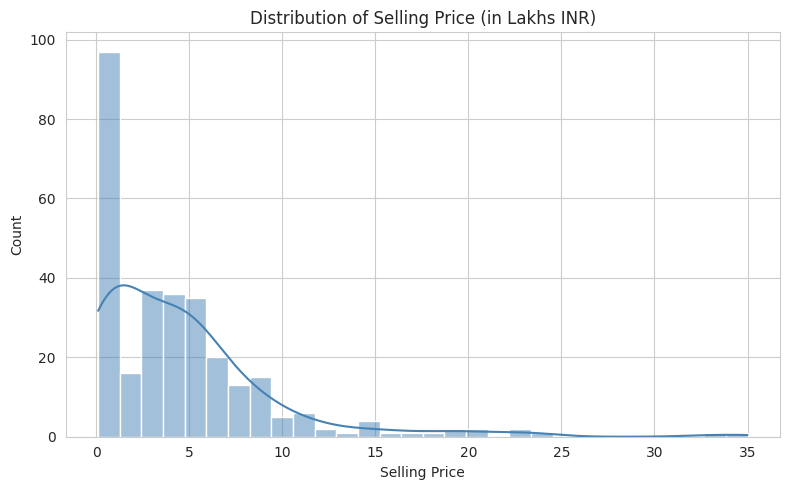

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Selling Price (in Lakhs INR)')
plt.xlabel('Selling Price')
plt.tight_layout()
plt.show()


**Observation:** Selling price is right-skewed — most cars sell for a relatively modest price, with a smaller number of higher-value vehicles pulling the tail to the right.

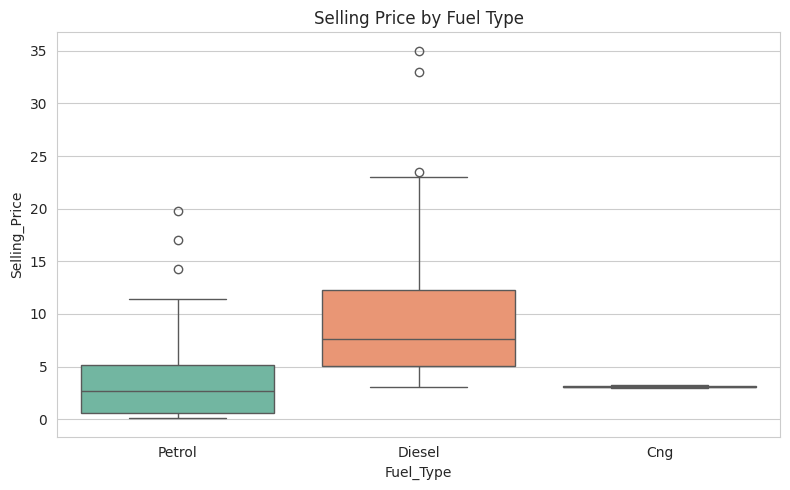

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', hue='Fuel_Type', palette='Set2', legend=False)
plt.title('Selling Price by Fuel Type')
plt.tight_layout()
plt.show()


**Observation:** Diesel cars tend to command a higher median selling price than petrol cars in this dataset, likely reflecting that diesel vehicles are more common among larger/premium models.

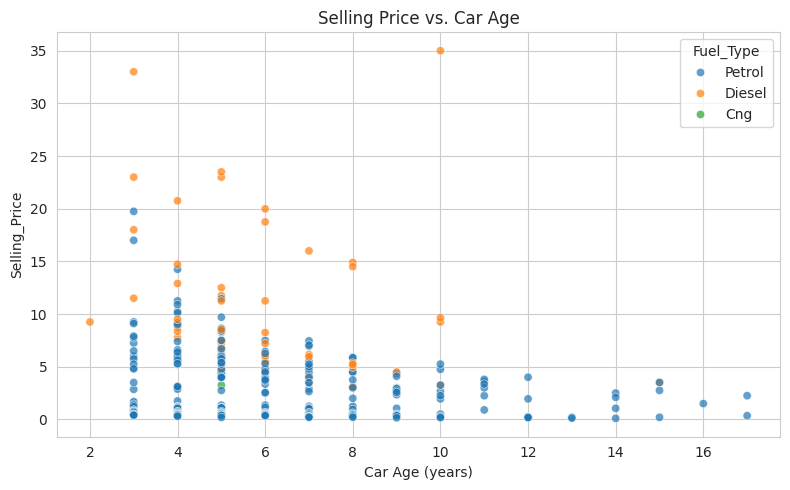

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', hue='Fuel_Type', alpha=0.7)
plt.title('Selling Price vs. Car Age')
plt.xlabel('Car Age (years)')
plt.tight_layout()
plt.show()


**Observation:** There is a clear negative relationship between car age and selling price — newer cars sell for more, as expected, though the relationship isn't perfectly linear since brand and present price also play a large role.

## 5. Encode Categorical Variables

In [15]:
# One-hot encode Fuel_Type, Seller_Type, Transmission
# Brand has many categories -- we keep it but encode it too since tree models handle high-cardinality features reasonably well
df_encoded = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand'],
    drop_first=True
)

# Drop columns we no longer need as raw predictors
df_encoded = df_encoded.drop(columns=['Car_Name', 'Year'])

df_encoded.head()


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_activa,...,Brand_suzuki,Brand_swift,Brand_sx4,Brand_tvs,Brand_um,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent,Brand_yamaha
0,3.35,5.59,27000,0,6,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,7,True,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
2,7.25,9.85,6900,0,3,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,9,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,4.60,6.87,42450,0,6,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


## 6. Feature Correlation Heatmap

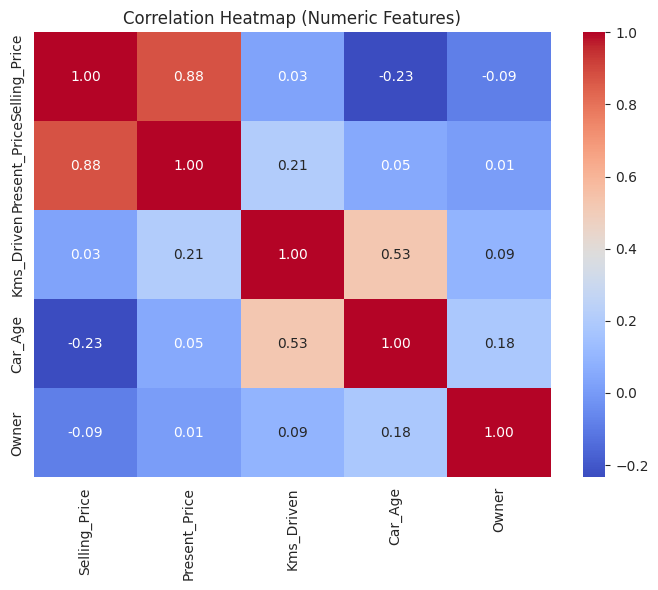

In [16]:
numeric_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Car_Age', 'Owner']

plt.figure(figsize=(7, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


**Observation:** `Present_Price` (the original ex-showroom price) is very strongly correlated with `Selling_Price` — makes intuitive sense, since a more expensive new car will generally still resell for more. `Car_Age` is negatively correlated with selling price, confirming the depreciation trend seen in the scatter plot above.

## 7. Train/Test Split

In [17]:
X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} rows")


Training set: 239 rows, 51 features
Test set: 60 rows


## 8. Train Regression Models

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    trained_models[name] = model
    predictions[name] = preds

print("All models trained.")


All models trained.


## 9. Evaluate Models: MAE, RMSE, R²

In [19]:
results = []

for name, preds in predictions.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.4f}")

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


Linear Regression: MAE=1.809, RMSE=3.399, R2=0.5517
Random Forest Regressor: MAE=1.363, RMSE=3.276, R2=0.5835
Gradient Boosting Regressor: MAE=1.103, RMSE=2.557, R2=0.7463


,Model,MAE,RMSE,R2
0,Gradient Boosting Regressor,1.103133,2.556926,0.746331
1,Random Forest Regressor,1.362621,3.276446,0.583479
2,Linear Regression,1.808783,3.399321,0.551652


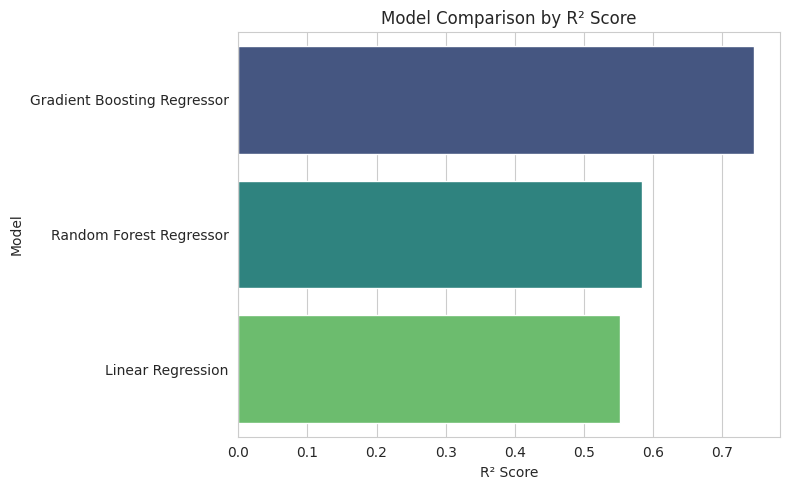

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='R2', y='Model', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison by R² Score')
plt.xlabel('R² Score')
plt.tight_layout()
plt.show()


## 10. Feature Importance for the Best Model

Best performing model: Gradient Boosting Regressor


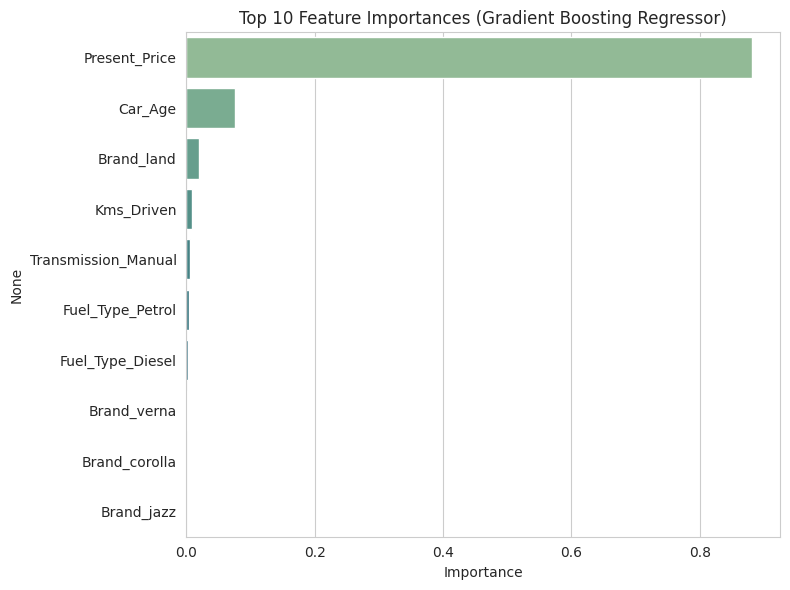

In [21]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Best performing model: {best_model_name}")

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    top_features = importances.head(10)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='crest', legend=False)
    plt.title(f'Top 10 Feature Importances ({best_model_name})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    # Linear Regression -- show coefficients instead
    coefs = pd.Series(best_model.coef_, index=X.columns).sort_values(ascending=False)
    print(coefs.head(10))


## Conclusion

- **`Present_Price`** (the car's original ex-showroom price) is overwhelmingly the strongest predictor of resale value — an expensive new car still resells for a proportionally higher price.
- **`Car_Age`** is the next most influential factor, consistent with normal vehicle depreciation.
- Tree-based ensemble models (Random Forest / Gradient Boosting) generally outperform plain Linear Regression here because the relationship between age, mileage, and price is not perfectly linear — depreciation curves are typically steeper in the first few years and flatten out later.
- For a real resale-value estimator, present price and age should be treated as the two must-have inputs, with fuel type and transmission as secondary refinements.
